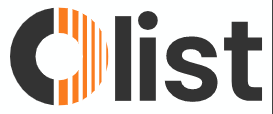

# Introduction
In this notebook, I will analyze the data and make a dashboard using the Brazilian E-Commerce Public Dataset by Olist. I will look into the company's store perfomance to bring insights on opportunites to improve overall customer satisfaction.

# About the Dataset
The dataset has information on 100,000 orders from 2016 to 2018 made at multiple marketplaces in Brazil. The orders include details such as order status, price, payment, freight performance to customer location, product attribute, and reviews written by customers. The geolocation data is associated to Brazilian zip codes with lattitude and longitude coordinates.

This is real commercial data, it has been anonymized, and references to the
companies and partners in the review text have been replaced.

# Tool Used
PowerBI

# Dashboard Site
https://app.powerbi.com/view?r=eyJrIjoiNjJlNWY1NGQtM2JjYi00Y2JjLTg1ZjQtYTE4ZTI1ZDAwZjVmIiwidCI6ImYzODExMmE3LWM5ZTktNDk2OC1hODMyLTE0YzhjN2QwZGY5NCIsImMiOjEwfQ%3D%3D

# Data Analysis Goals
1. Explore the company's product volume, sales, and customer satisfaction rating for products.
2. Analyze delivery performance.
3. Investigate product ratings and discover product categories that are prone to customer dissatisfaction.

# Importing the Dataset
The dataset includes 9 csv files imported to PowerBI. The dataset can be downloaded [here](https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce).

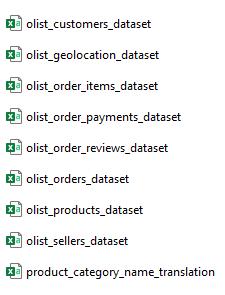

# Exploring and Cleaning the Dataset
The dataset is loaded and transformed in PowerQuery Editor. Most of the dataset needed their headers to be promoted as PowerQuery wasn't able to recognize those immediately. Most data also needed their data types to be changed. I went ahead and replaced jargons with proper terms for easy understanding especially the "product_category_name_translation" query.


# Analyzing the Dataset and Answering the Data Analysis Goals
I created the first page of the dashboard showcasing information about the company's total sales, total products sold, total products for sale, and average product rating using visualization cards.

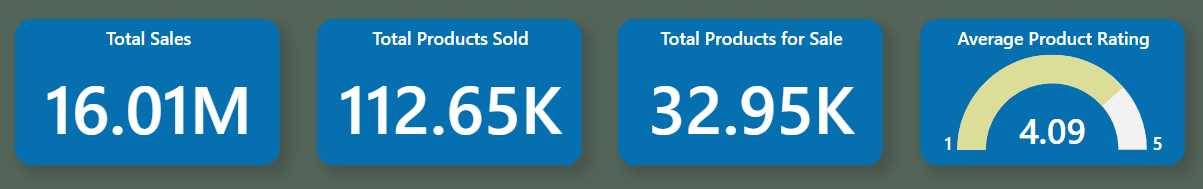

Below that, I inserted a funnel chart with a breakdown of the top 10 best selling product categories. This also shows the total number of orders per category and a quick comparison of total order volume.

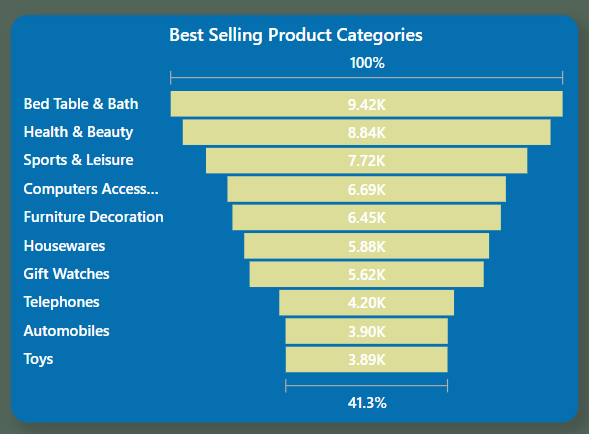

Beside the funnel chart, I also inserted a column chart showing total sales volume broken down in months from September 2016 until September 2018. There aren't much data on the month of September 2018 hence the low values.

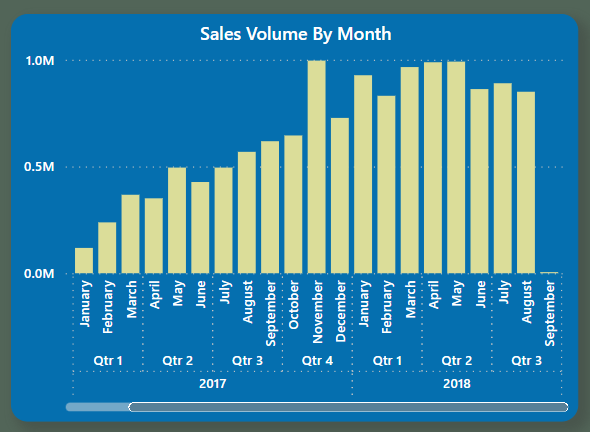

To further slice the dataset, I placed a filter pane on the left side of the dashboard for Product Category, Order Status, State of Brazil, Seller ID, and Payment Type. This can help in focusing on certain categories like order performance in specific locations or top product categories sold per seller.

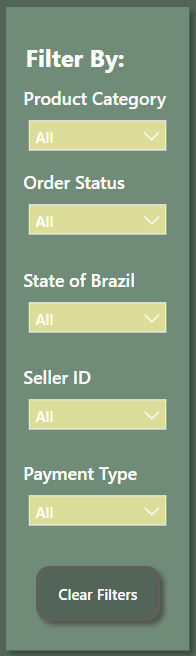

For the second page, I am trying to figure out the company's delivery performance. I did additional data transformation by creating DAX measures to calculate the following:
1. Order processing time in minutes and hours
2. Number of days order is sent by seller to carrier
3. Number of days order is sent by carrier to customer
4. Number of days order is delivered to customer date versus expected customer delivery date
5. Number of days order is approved by seller until customer delivery date.

Below are the DAX formulas for the respective measures.

In [ ]:
1.A. order_processing_time = DATEDIFF((olist_orders_dataset[order_purchase_timestamp]), 
                                      (olist_orders_dataset[order_approved_at]), MINUTE)

1.B. order_processing_(hours) = DATEDIFF((olist_orders_dataset[order_purchase_timestamp]), 
                                         (olist_orders_dataset[order_approved_at]), HOUR)

In [ ]:
2. order_sent_to_carrier_(days) = DATEDIFF((olist_orders_dataset[order_approved_at]), 
                                           (olist_orders_dataset[order_delivered_carrier_date]), DAY)

In [ ]:
3. order_sent_to_customer_(days) = DATEDIFF((olist_orders_dataset[order_delivered_carrier_date]), 
                                            (olist_orders_dataset[order_delivered_customer_date]), DAY)

In [ ]:
4. order_est_vs_del_customer_(days) = DATEDIFF((olist_orders_dataset[order_delivered_customer_date]), 
                                               (olist_orders_dataset[order_estimated_delivery_date]), DAY)

In [ ]:
5. seller_to_customer_(days) = DATEDIFF((olist_orders_dataset[order_approved_at]), 
                                        (olist_orders_dataset[order_delivered_customer_date]), DAY)

Next, I performed table joins using Merge Queries. I performed the following joins:
1. Olist customer dataset zip code and state with Olist orders dataset.
2. Olist geolocation dataset lattitude and longitude with customer zip code join on Olist orders dataset.

These transformations were needed to make the visualizations work in the second dashboard.

On the top section, I placed cards to show the number of orders delivered late, number of orders dispatched late by the seller, average order processing time in hours, average days order is shipped by seller to carrier, and average days order is shipped by carrier to customer.

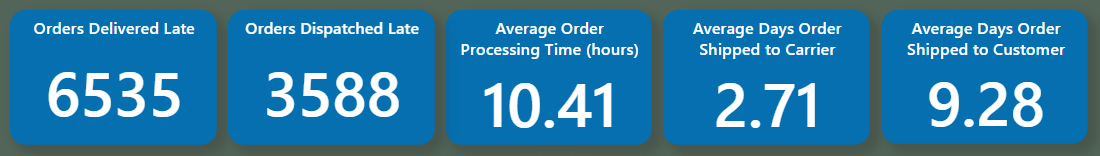

Below that, I inserted a map showing various customer order status in different locations at Brazil.

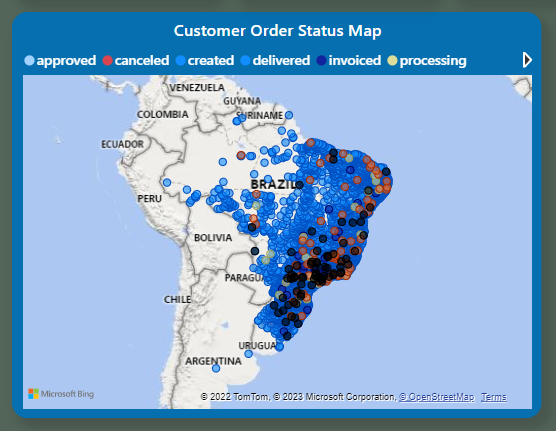

Then I made a scatter chart showing the relationship between average customer order price versus average delivery time to customer and placed it beside the map.

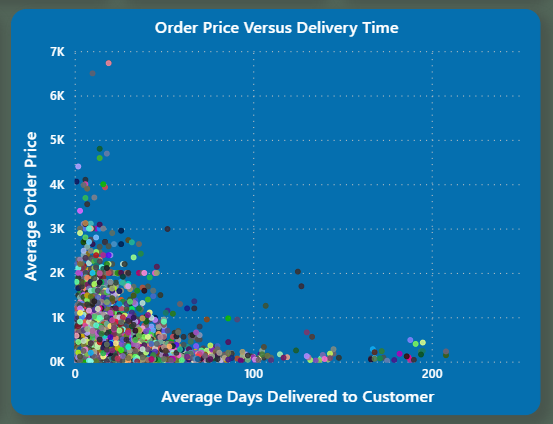

Similarly, I placed a filter pane on the left side of the dashboard for Product Category, Order Status, State of Brazil, Year Purchased, and Payment Type. This can help in focusing on certain categories like order status and delivery performance of respective product categories and average order price of certain payment methods versus its average delivery time to customers.

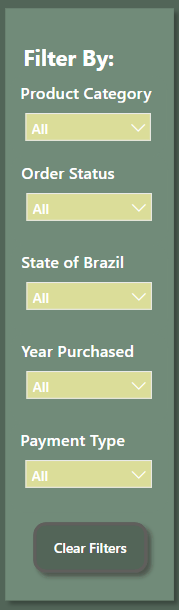

For the third page, I'm focusing on product rating statistics and product categories. I executed another table join that covers the Product category name in English with the Olist products dataset. This join is needed to show the product rating per product category.

At the top left of the dashboard, we'll see the product statistics such as total number of reviews, total number of 5 star reviews, total number of 1 star reviews, and total number of bad reviews. The bad reviews are categorized as products with review scores less than or equal to 3.

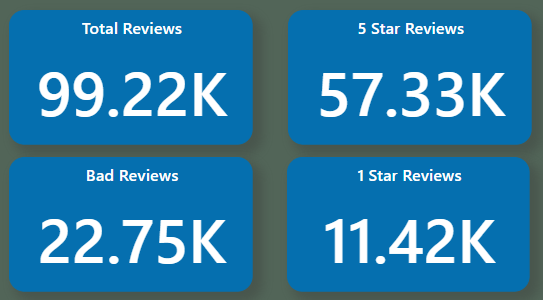

Below it is the distribution of orders categorized by review score.

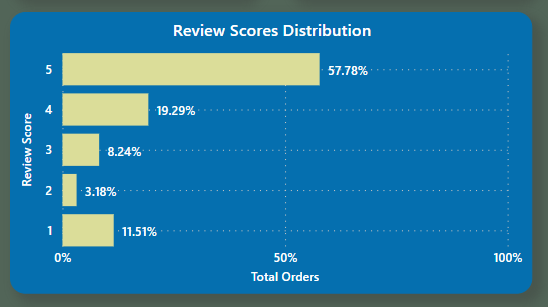

Beside the aforementioned two visualizations are the top rated and least rated product categories offered by Olist eCommerce.

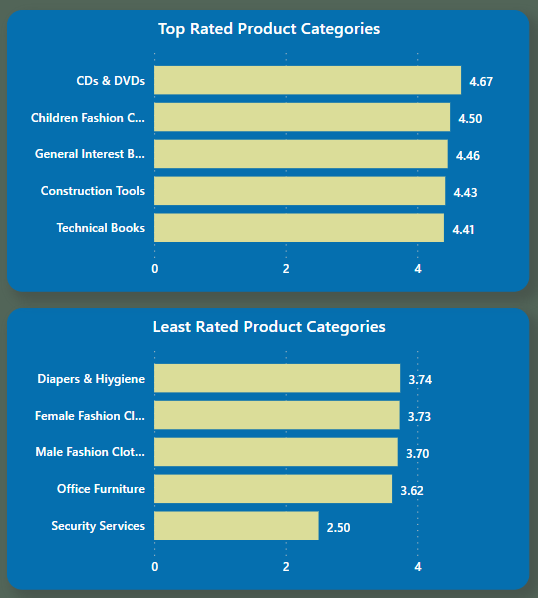

I also placed a similar filter pane on the left side of the dashboard for Product Category, Order Year, Order Month, Seller ID, and State of Brazil. This can help in focusing on certain categories like top rated product categories per seller and/or state and number of reviews per seller and their review score distribution.

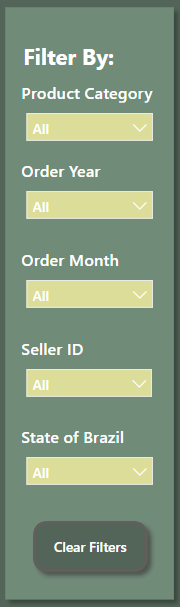

The PowerBI dashboard also includes a fourth page about my insights, recommendations, and summary about Olist eCommerce company performance.

# Insights
According to the data, Olist E-commerce has about 99,440 orders. With about 89,940 orders being delivered, the company has a 90% delivery success rate. Their average product rating is 4.09 stars, with product categories going as high as 4.67 stars and as low as 2.5 stars. 1 Star reviews are on third place in the review score distribution ranking which likely indicates that there could be problems with product quality in some product categories. Delivery performance could also influence review scores and success rate could certainly be improved.

# Recommendations
1. Regularly monitor and analyze customer reviews to gain insights in product quality and identify areas for improvement. Dashboards can be used to identify patterns in customer reviews. This will provide a data-driven approach to enhance customer experience.

2. Investigate delivery delays and undelivered orders. Analyzing geographic locations could bring insights about certain challenges with demographics, accessibility, and possible route optimization. Tracking fleet performance with the use of telematics can help identify issues before they become a problem.

3. Providing a proper shipment tracking system aids in having clear and concise communication between customers, sellers and couriers. Regular updates can set proper expectations among customers and specific delivery instructions of customers can be properly accommodated. By establishing trust and communication, both parties can work together to resolve any issues that may arise.

# Summary
Overall, regular monitoring of customer reviews, real-time tracking of fleet performance, together with proper shipment tracking and communication system can improve Olist's delivery and supply chain performance and ensure customers are highly satisfied with the service.